In [6]:
!pip install ultralytics transformers -q

In [7]:
import os
os.system('wget -q -O /kaggle/working/best.pt "https://github.com/astitwarajawat/ai_shelf_monitoring/raw/main/best.pt"')
print(os.path.exists("/kaggle/working/best.pt"))  # should print True

True


In [8]:
import os
for root, dirs, files in os.walk('/kaggle'):
    for f in files:
        if f.endswith(('.mp4', '.avi', '.mov', '.mkv')):
            print(os.path.join(root, f))

Using: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded!
Extracting frames...
Video   : 20.6s  |  60.0 fps  |  1236 frames
Grabbing frames at: [1.0, 19.8] seconds
  t=1.00s → 55 detections
  t=19.79s → 43 detections

Extracted 2 frames

Processing 2 frames...

  Frame 1 (t=1.00s): REFERENCE FRAME — running DBSCAN and locking groups...
  [ReferenceGroupAnchors] Locked 3 groups from first frame.
    Group 0: 29 initial members
    Group 1: 22 initial members
    Group 2: 4 initial members
  Group 0: baseline set → 29
  Group 1: baseline set → 22
  Group 2: baseline set → 4
  [  1/2] t=   1.0s  total= 55  G0:IN   G1:IN   G2:IN 
  Frame 2 (t=19.79s): assigning to locked reference groups...
  Group 2: restock detected 4 → 5 (new baseline)
  [  2/2] t=  19.8s  total= 43  G0:IN   G1:IN   G2:IN 

Baseline per group (max count ever seen):
  Group 0: 29
  Group 1: 22
  Group 2: 5

Frames processed : 2

Latest stock status (t=19.8s):
───────────────────────────────────────────────────────
Group    Row      Count    Baseline   Status
────

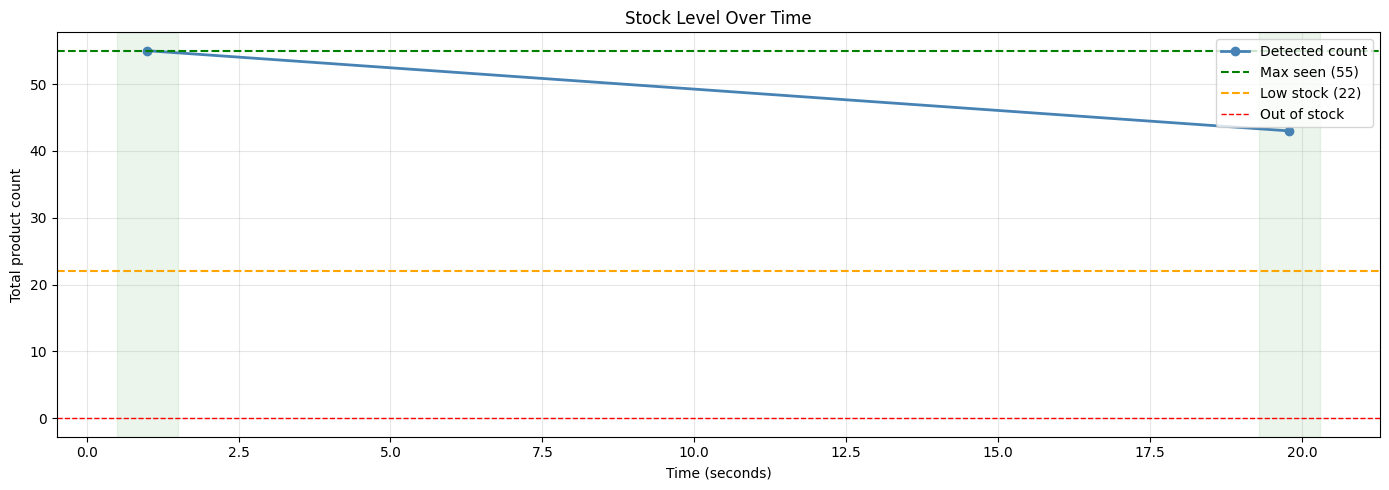

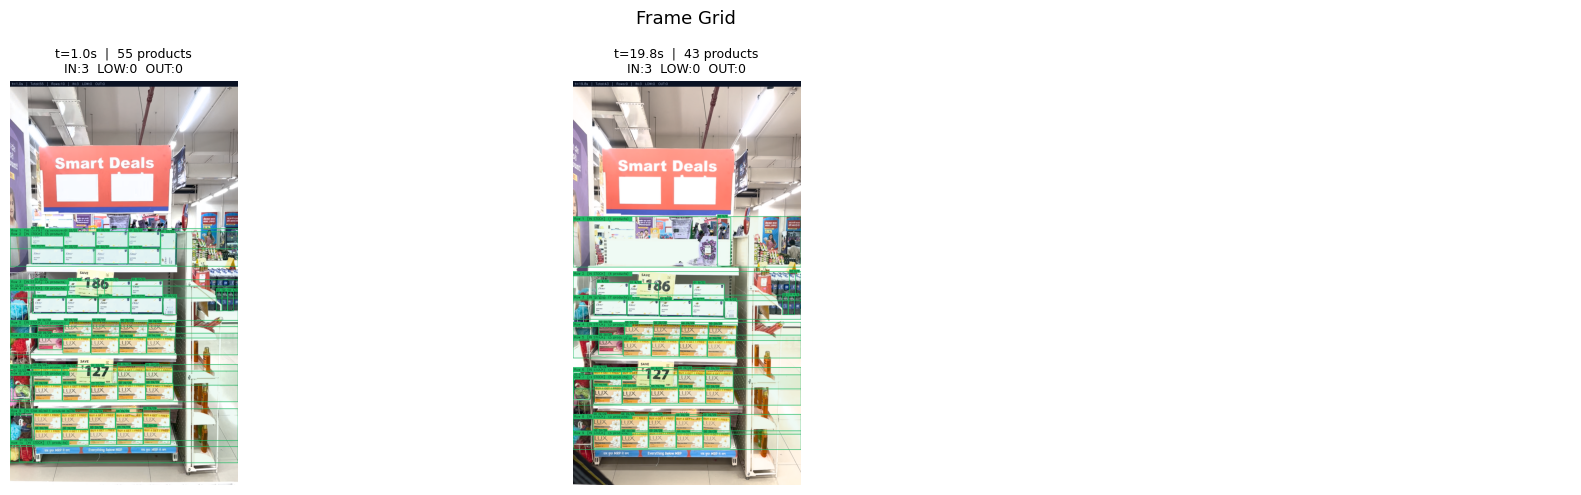

Showing 2 frames (one every 4s)



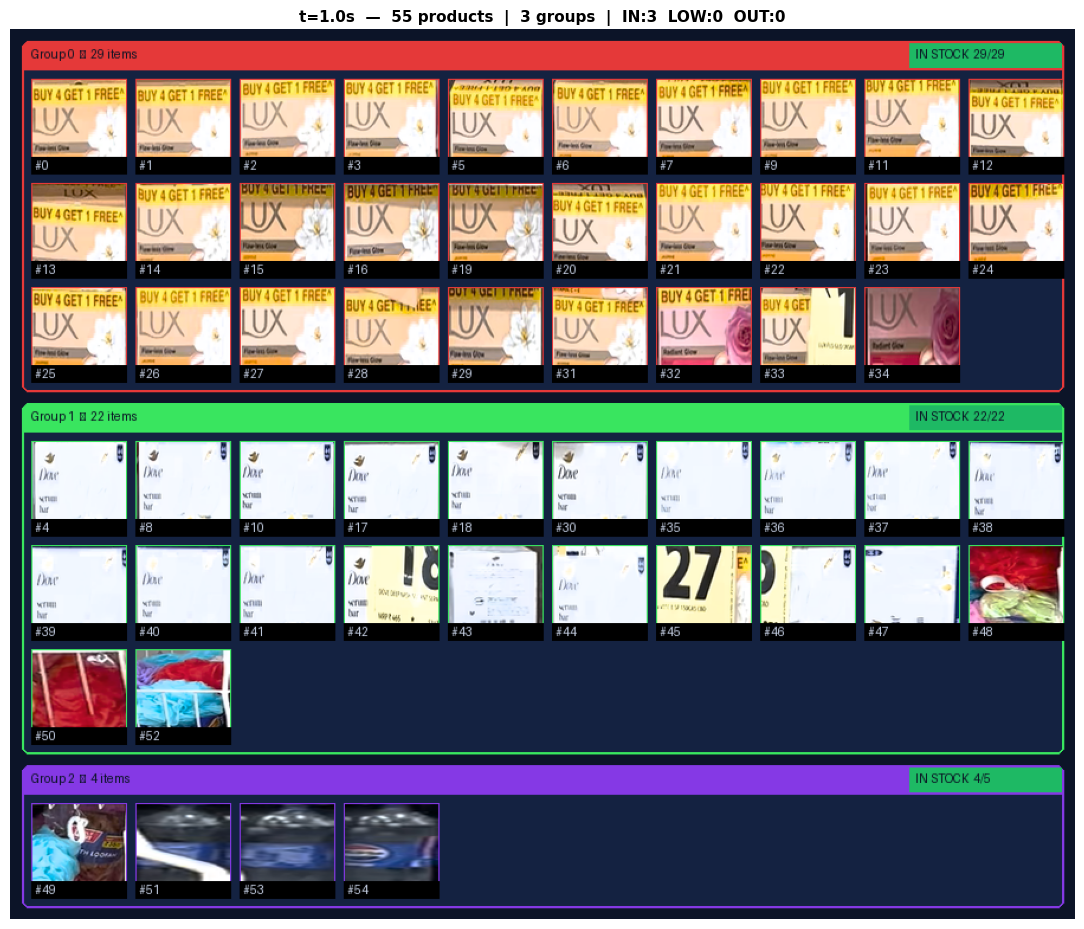

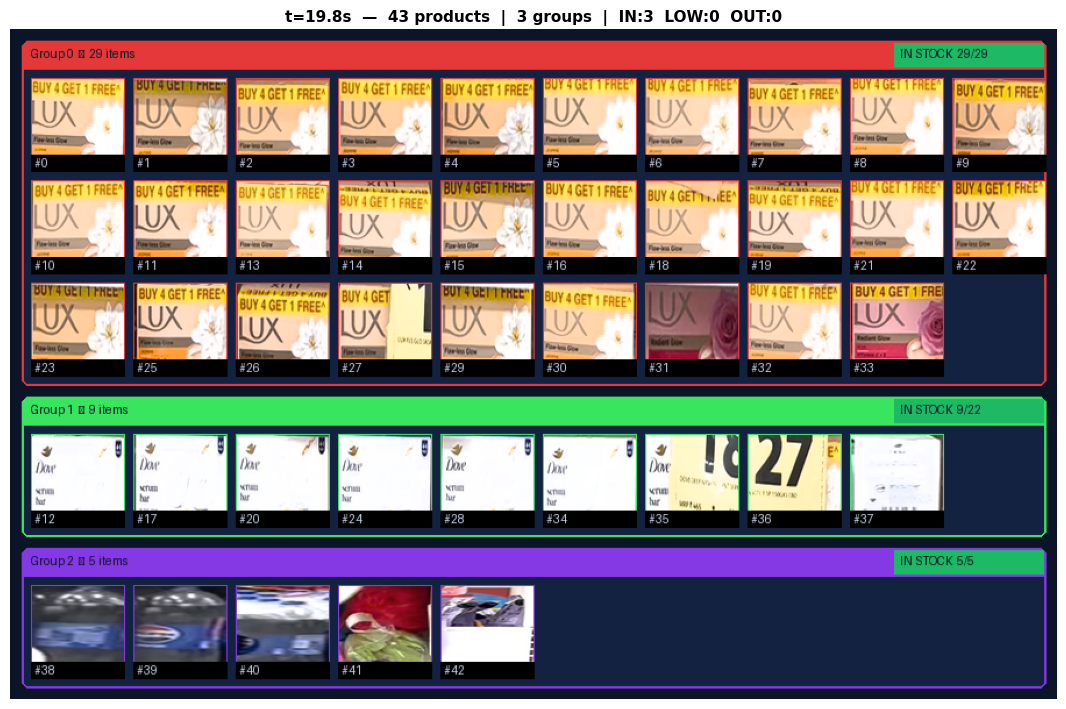

✅  No stock alerts — all products in stock


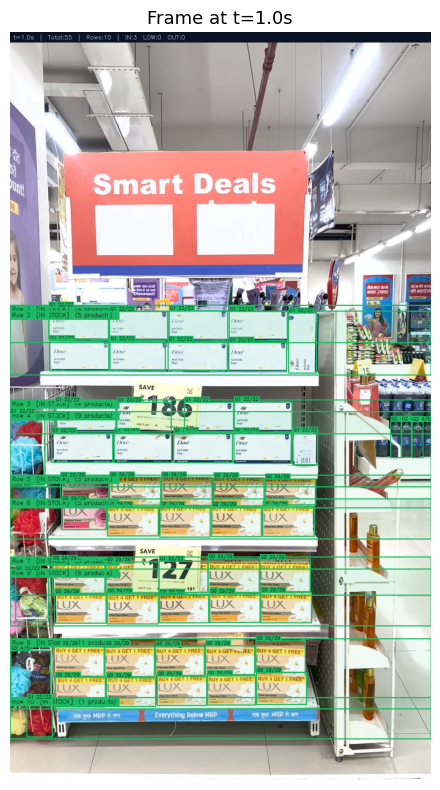


Frame details  (t=1.0s):
──────────────────────────────────────────────────
Group    Row      Count    Baseline   Status
──────────────────────────────────────────────────
0        Row 9    29       29         ✅ IN STOCK
1        Row 9    22       22         ✅ IN STOCK
2        Row 9    4        5          ✅ IN STOCK
Saved → /kaggle/working/stock_report.json


In [9]:
# ============================================================
# CELL 1 - Install
# ============================================================
# !pip install ultralytics transformers -q


# ============================================================
# CELL 2 - Imports
# ============================================================
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw, ImageFont
from transformers import CLIPProcessor, CLIPModel
from ultralytics import YOLO
from sklearn.cluster import DBSCAN
import colorsys, math, os, json
from collections import defaultdict

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")


# ============================================================
# CELL 3 - Config
# ============================================================
CONFIG = {
    # paths
    "model_path"  : "/kaggle/input/datasets/astitwarajawat/yolo-model/best.pt",
    "video_path": "/kaggle/input/datasets/cogknight/videostesting/IMG_3412.MOV",

    # ── NEW: extract ONLY these timestamps (seconds) ──────────
    # Set to None to use target_fps sampling instead
    "target_timestamps" : [1.0, 19.8],   # 00:01 and 00:19

    # frame extraction (used only if target_timestamps is None)
    "target_fps"          : 2,
    "min_detection_ratio" : 0.5,
    "blur_threshold"      : 80,

    # detection
    "conf"        : 0.25,
    "iou"         : 0.45,
    "min_box_size": 20,

    # CLIP clustering (used only on the FIRST / reference frame)
    "clip_eps"       : 0.10,
    "clip_min_samp"  : 2,

    # ── NEW: group locking ────────────────────────────────────
    # Minimum cosine similarity to assign a crop to a reference group.
    # Crops below this become group -1 (unmatched).
    "lock_threshold" : 0.55,

    # stock thresholds
    "low_stock_pct" : 0.40,
}


# ============================================================
# CELL 4 - Load models
# ============================================================
import os
os.system('wget -q -O /kaggle/working/best.pt "https://github.com/astitwarajawat/ai_shelf_monitoring/raw/main/best.pt"')

shelf_model = YOLO("/kaggle/working/best.pt")
clip_model  = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor   = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval().to(device)
print("Models loaded!")


# ============================================================
# CELL 5 - Frame extraction
#
# TWO MODES:
#   1. target_timestamps is set → grab exactly those seconds
#   2. target_timestamps is None → original target_fps sampling
# ============================================================

def _run_yolo_on_frame(frame_rgb, config):
    """Run YOLO on a single RGB frame, return list of (x1,y1,x2,y2) boxes."""
    results = shelf_model(
        frame_rgb,
        conf=config["conf"],
        iou=config["iou"],
        verbose=False
    )[0]
    boxes = []
    for box in results.boxes.xyxy.cpu().numpy().astype(int):
        x1, y1, x2, y2 = box
        if ((x2 - x1) >= config["min_box_size"] and
                (y2 - y1) >= config["min_box_size"]):
            boxes.append((x1, y1, x2, y2))
    return boxes


def extract_specific_timestamps(video_path, config):
    """
    Extract frames at exactly the seconds listed in config['target_timestamps'].
    Returns (usable_frames, []) — no filtering needed for a hand-picked test set.
    """
    target_ts = config["target_timestamps"]
    cap       = cv2.VideoCapture(video_path)
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    total     = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration  = total / video_fps

    print(f"Video   : {duration:.1f}s  |  {video_fps:.1f} fps  |  {total} frames")
    print(f"Grabbing frames at: {target_ts} seconds")

    usable = []
    for ts in sorted(target_ts):
        frame_idx = int(round(ts * video_fps))
        frame_idx = min(frame_idx, total - 1)

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            print(f"  ⚠  Could not read frame at t={ts:.2f}s (idx {frame_idx})")
            continue

        actual_ts = frame_idx / video_fps
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        boxes     = _run_yolo_on_frame(frame_rgb, config)

        print(f"  t={actual_ts:.2f}s → {len(boxes)} detections")
        usable.append({
            "frame"    : frame_rgb,
            "timestamp": actual_ts,
            "usable"   : True,
            "reason"   : "OK",
            "n_det"    : len(boxes),
            "boxes"    : boxes,
        })

    cap.release()
    print(f"\nExtracted {len(usable)} frames")
    return usable, []


def extract_and_filter_frames(video_path, config):
    """
    Original fps-based extraction with blur + low-detection filtering.
    Used when config['target_timestamps'] is None.
    """
    target_fps    = config.get("target_fps", 2)
    min_det_ratio = config.get("min_detection_ratio", 0.5)

    cap       = cv2.VideoCapture(video_path)
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    total     = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration  = total / video_fps
    step      = max(1, int(video_fps / target_fps))

    print(f"Video   : {duration:.1f}s  |  {video_fps:.1f} fps  |  {total} frames")
    print(f"Sampling: every {step} frames  ({target_fps} fps effective)")

    all_frames = []
    frame_idx  = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % step == 0:
            ts        = frame_idx / video_fps
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            gray       = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)
            blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

            if blur_score < config.get("blur_threshold", 80):
                all_frames.append({
                    "frame": frame_rgb, "timestamp": ts,
                    "usable": False, "reason": f"Blurry ({blur_score:.0f})",
                    "n_det": 0, "boxes": []
                })
                frame_idx += 1
                continue

            boxes = _run_yolo_on_frame(frame_rgb, config)
            all_frames.append({
                "frame": frame_rgb, "timestamp": ts,
                "usable": None, "reason": "OK",
                "n_det": len(boxes), "boxes": boxes
            })

        frame_idx += 1

    cap.release()

    if not all_frames:
        print("No frames extracted")
        return [], []

    det_counts = [f["n_det"] for f in all_frames if f["usable"] is not False]
    expected   = np.percentile(det_counts, 75) if det_counts else 0
    print(f"\nExpected product count (75th percentile): {expected:.0f}")

    usable, unusable = [], []
    for f in all_frames:
        if f["usable"] is False:
            unusable.append(f)
            continue
        ratio = f["n_det"] / expected if expected > 0 else 0
        if ratio < min_det_ratio:
            f["usable"] = False
            f["reason"] = (f"Low detections {f['n_det']}"
                           f" ({ratio*100:.0f}% of expected {expected:.0f})"
                           f" — possible obstruction")
            unusable.append(f)
        else:
            f["usable"] = True
            usable.append(f)

    print(f"Usable  : {len(usable)}  |  Filtered: {len(unusable)}")
    return usable, unusable


# ============================================================
# CELL 5B - CLIP embedding helpers
# ============================================================

def get_clip_embeddings(crops, batch_size=32):
    if not crops:
        return np.array([])
    all_emb = []
    for i in range(0, len(crops), batch_size):
        batch  = [Image.fromarray(c) for c in crops[i:i+batch_size]]
        inputs = processor(images=batch, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = clip_model.vision_model(pixel_values=inputs["pixel_values"])
            emb = clip_model.visual_projection(out.pooler_output)
        emb = emb / emb.norm(dim=-1, keepdim=True)
        all_emb.append(emb.cpu().numpy())
    return np.vstack(all_emb)


# ============================================================
# CELL 5B-2 - GROUP LOCKING  ← KEY NEW LOGIC
#
# ReferenceGroupAnchors
#   - Built from the FIRST usable frame using DBSCAN.
#   - Stores a centroid embedding per group (mean of all member embeddings).
#   - All later frames assign each crop to the nearest anchor via cosine sim.
#   - Group IDs are now stable across every frame.
# ============================================================

class ReferenceGroupAnchors:
    """
    Stores the reference (locked) group centroids from frame 1.
    After locking, every frame uses assign() instead of DBSCAN.
    """

    def __init__(self):
        self.anchors    = {}   # {group_id: centroid_embedding (1-D, L2-normalised)}
        self.is_locked  = False
        self.n_groups   = 0

    # ----------------------------------------------------------
    # Call this ONCE on the first frame
    # ----------------------------------------------------------
    def lock_from_frame(self, embeddings, config):
        """
        Run DBSCAN on `embeddings`, compute per-group centroids,
        and lock them as reference anchors.

        Returns the initial label list (same as if cluster_crops ran).
        """
        if len(embeddings) == 0:
            return []

        raw_labels = DBSCAN(
            eps=config["clip_eps"],
            min_samples=config["clip_min_samp"],
            metric="cosine"
        ).fit(embeddings).labels_.tolist()

        # force-assign noise points to nearest group (same as before)
        sim_matrix = embeddings @ embeddings.T
        for i, label in enumerate(raw_labels):
            if label != -1:
                continue
            best_group, best_sim = None, -1
            for j, other in enumerate(raw_labels):
                if other == -1 or i == j:
                    continue
                s = float(sim_matrix[i][j])
                if s > best_sim:
                    best_sim, best_group = s, other
            # use force_threshold to decide whether to assign or leave as -1
            if (best_group is not None and
                    best_sim >= config.get("lock_threshold", 0.55)):
                raw_labels[i] = best_group

        # compute centroids for each group
        group_embs = defaultdict(list)
        for i, lbl in enumerate(raw_labels):
            if lbl != -1:
                group_embs[lbl].append(embeddings[i])

        self.anchors = {}
        for gid, embs in group_embs.items():
            centroid = np.mean(embs, axis=0)
            centroid /= np.linalg.norm(centroid) + 1e-9
            self.anchors[gid] = centroid

        self.is_locked = True
        self.n_groups  = len(self.anchors)

        print(f"  [ReferenceGroupAnchors] Locked {self.n_groups} groups "
              f"from first frame.")
        for gid, c in self.anchors.items():
            count = raw_labels.count(gid)
            print(f"    Group {gid}: {count} initial members")

        return raw_labels

    # ----------------------------------------------------------
    # Call this on EVERY subsequent frame
    # ----------------------------------------------------------
    def assign(self, embeddings, config):
        """
        Assign each embedding to the closest locked anchor.
        Returns a label list using the SAME group IDs as frame 1.
        """
        if not self.is_locked or len(embeddings) == 0:
            return []

        threshold = config.get("lock_threshold", 0.55)
        anchor_ids   = list(self.anchors.keys())
        anchor_matrix = np.stack([self.anchors[gid] for gid in anchor_ids])
        # cosine similarity: embeddings are already L2-normalised
        sim = embeddings @ anchor_matrix.T   # (n_crops, n_anchors)

        labels = []
        for i in range(len(embeddings)):
            best_idx = int(np.argmax(sim[i]))
            best_sim = float(sim[i, best_idx])
            if best_sim >= threshold:
                labels.append(anchor_ids[best_idx])
            else:
                labels.append(-1)   # unmatched / new product type

        return labels


# ============================================================
# CELL 5C - Row detection helpers
# ============================================================

def detect_shelf_rows(frame_rgb, boxes):
    if not boxes:
        return []
    y_centers  = np.array([(y1+y2)/2 for _,y1,_,y2 in boxes])
    sorted_idx = np.argsort(y_centers)
    sorted_y   = y_centers[sorted_idx]
    avg_box_h  = np.mean([y2-y1 for _,y1,_,y2 in boxes])
    gap_thresh = avg_box_h * 0.5

    rows, current = [], [sorted_idx[0]]
    for i in range(1, len(sorted_idx)):
        if sorted_y[i] - sorted_y[i-1] > gap_thresh:
            rows.append(current)
            current = []
        current.append(sorted_idx[i])
    rows.append(current)

    row_results = []
    for row_id, indices in enumerate(rows):
        row_boxes = [boxes[i] for i in indices]
        row_results.append({
            "row_id"     : row_id,
            "y_min"      : min(b[1] for b in row_boxes) - 5,
            "y_max"      : max(b[3] for b in row_boxes) + 5,
            "y_center"   : int(np.mean([(y1+y2)/2 for _,y1,_,y2 in row_boxes])),
            "box_indices": indices,
            "n_boxes"    : len(indices),
        })
    return row_results


def assign_boxes_to_rows(boxes, rows):
    box_to_row = {}
    for row in rows:
        for idx in row["box_indices"]:
            box_to_row[idx] = row["row_id"]
    return box_to_row


# ============================================================
# CELL 5D - Product image bank
# ============================================================

class ProductImageBank:
    def __init__(self):
        self.last_seen = {}
        self.row_map   = {}

    def update(self, crops, labels, boxes, box_to_row):
        for i, (crop, label) in enumerate(zip(crops, labels)):
            if label == -1:
                continue
            self.last_seen[label] = crop.copy()
            self.row_map[label]   = box_to_row.get(i, -1)

    def get_alerts(self, stock_status):
        oos, low = [], []
        for gid, status in stock_status.items():
            if gid not in self.last_seen:
                continue
            entry = {
                "group_id"       : gid,
                "row_id"         : self.row_map.get(gid, -1),
                "last_seen_crop" : self.last_seen[gid],
                "status"         : status,
            }
            if status == "OUT OF STOCK":
                oos.append(entry)
            elif status == "LOW STOCK":
                low.append(entry)
        return oos, low


# ============================================================
# CELL 6 - Stock tracker  (updated to use ReferenceGroupAnchors)
# ============================================================

class StockTracker:

    def __init__(self, config):
        self.config         = config
        self.group_baseline = {}
        self.history        = []
        self.frame_no       = 0
        self.product_bank   = ProductImageBank()
        # ── NEW ──────────────────────────────────────────────
        self.anchors        = ReferenceGroupAnchors()

    def update_baseline(self, counts):
        updated = []
        for gid, cnt in counts.items():
            prev = self.group_baseline.get(gid, 0)
            if cnt > prev:
                self.group_baseline[gid] = cnt
                updated.append((gid, prev, cnt))
        if updated:
            for gid, old, new in updated:
                if old == 0:
                    print(f"  Group {gid}: baseline set → {new}")
                else:
                    print(f"  Group {gid}: restock detected "
                          f"{old} → {new} (new baseline)")

    def get_stock_status(self, group_id, count):
        baseline = self.group_baseline.get(group_id, 0)
        if baseline == 0:
            return "UNKNOWN"
        if count == 0:
            return "OUT OF STOCK"
        elif count / baseline < self.config["low_stock_pct"]:
            return "LOW STOCK"
        else:
            return "IN STOCK"

    def get_row_status(self, rows, labels, stock_status):
        priority   = {"OUT OF STOCK": 3, "LOW STOCK": 2,
                      "IN STOCK": 1, "UNKNOWN": 0}
        row_status = {}
        for row in rows:
            worst = "IN STOCK"
            for idx in row["box_indices"]:
                if idx < len(labels):
                    gid    = labels[idx]
                    status = stock_status.get(gid, "UNKNOWN")
                    if priority.get(status, 0) > priority.get(worst, 0):
                        worst = status
            row_status[row["row_id"]] = worst
        return row_status

    def process_frame(self, frame_rgb, timestamp, boxes):
        self.frame_no += 1
        result = {
            "frame_no"    : self.frame_no,
            "timestamp"   : timestamp,
            "total_count" : 0,
            "group_counts": {},
            "group_baseline_snapshot": {},
            "stock_status": {},
            "row_status"  : {},
            "rows"        : [],
            "box_to_row"  : {},
            "frame_rgb"   : frame_rgb,
            "boxes"       : boxes,
            "labels"      : [],
        }

        if not boxes:
            return result

        rows       = detect_shelf_rows(frame_rgb, boxes)
        box_to_row = assign_boxes_to_rows(boxes, rows)
        result["rows"]       = rows
        result["box_to_row"] = box_to_row

        crops      = [frame_rgb[y1:y2, x1:x2] for x1,y1,x2,y2 in boxes]
        embeddings = get_clip_embeddings(crops)

        # ── GROUP LOCKING LOGIC ───────────────────────────────
        if not self.anchors.is_locked:
            # First frame: run DBSCAN and lock the anchors
            print(f"  Frame {self.frame_no} (t={timestamp:.2f}s): "
                  f"REFERENCE FRAME — running DBSCAN and locking groups...")
            labels = self.anchors.lock_from_frame(embeddings, self.config)
        else:
            # All subsequent frames: assign to locked anchors
            print(f"  Frame {self.frame_no} (t={timestamp:.2f}s): "
                  f"assigning to locked reference groups...")
            labels = self.anchors.assign(embeddings, self.config)
        # ─────────────────────────────────────────────────────

        result["labels"] = labels

        counts = defaultdict(int)
        for l in labels:
            if l != -1:
                counts[l] += 1
        counts = dict(counts)

        result["group_counts"] = counts
        result["total_count"]  = sum(counts.values())

        self.update_baseline(counts)
        result["group_baseline_snapshot"] = self.group_baseline.copy()

        for gid, cnt in counts.items():
            result["stock_status"][gid] = self.get_stock_status(gid, cnt)

        result["row_status"] = self.get_row_status(
            rows, labels, result["stock_status"]
        )

        self.product_bank.update(crops, labels, boxes, box_to_row)
        self.history.append(result)
        return result

    def summary(self):
        if not self.history:
            print("No frames processed")
            return
        last = self.history[-1]
        print(f"\n{'='*55}")
        print(f"Frames processed : {self.frame_no}")
        print(f"\nLatest stock status (t={last['timestamp']:.1f}s):")
        print(f"{'─'*55}")
        print(f"{'Group':<8} {'Row':<8} {'Count':<8} "
              f"{'Baseline':<10} {'Status'}")
        print(f"{'─'*55}")
        STATUS_ICON = {
            "IN STOCK"    : "✅",
            "LOW STOCK"   : "⚠️ ",
            "OUT OF STOCK": "🔴",
            "UNKNOWN"     : "❓",
        }
        for gid, status in last["stock_status"].items():
            cnt      = last["group_counts"].get(gid, 0)
            baseline = self.group_baseline.get(gid, "?")
            row_id   = last["box_to_row"].get(gid, -1)
            row_lbl  = f"Row {row_id+1}" if row_id >= 0 else "—"
            icon     = STATUS_ICON.get(status, "❓")
            print(f"{gid:<8} {row_lbl:<8} {cnt:<8} "
                  f"{str(baseline):<10} {icon} {status}")
        print(f"{'='*55}")


# ============================================================
# CELL 7 - Visualization helpers (unchanged)
# ============================================================

STATUS_COLORS = {
    "IN STOCK"    : (30,  185, 100),
    "LOW STOCK"   : (240, 140, 30),
    "OUT OF STOCK": (220, 50,  50),
    "UNKNOWN"     : (150, 150, 150),
}

ROW_COLORS = {
    "IN STOCK"    : (30,  185, 100),
    "LOW STOCK"   : (240, 140, 30),
    "OUT OF STOCK": (220, 50,  50),
    "UNKNOWN"     : (150, 150, 150),
}


def hsv_color(i, n):
    r, g, b = colorsys.hsv_to_rgb(i/max(n,1), 0.85, 0.95)
    return (int(r*255), int(g*255), int(b*255))


def draw_annotated_frame(result, tracker):
    frame   = result["frame_rgb"].copy()
    boxes   = result["boxes"]
    labels  = result["labels"]
    status  = result["stock_status"]
    counts  = result["group_counts"]
    rows    = result["rows"]
    h, w    = frame.shape[:2]

    for row in rows:
        rs     = result["row_status"].get(row["row_id"], "UNKNOWN")
        color  = ROW_COLORS[rs]
        y1, y2 = max(0, row["y_min"]), min(h, row["y_max"])

        overlay = frame.copy()
        cv2.rectangle(overlay, (0,y1), (w,y2), color, -1)
        cv2.addWeighted(overlay, 0.07, frame, 0.93, 0, frame)
        cv2.rectangle(frame, (0,y1), (w,y2), color, 2)

        row_label = (f"Row {row['row_id']+1}  "
                     f"[{rs}]  "
                     f"({row['n_boxes']} products)")
        cv2.rectangle(frame, (0,y1), (280, y1+22), color, -1)
        cv2.putText(frame, row_label, (5, y1+15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.48, (10,10,10), 1)

    for i, (box, label) in enumerate(zip(boxes, labels)):
        x1, y1, x2, y2 = box
        st    = status.get(label, "UNKNOWN")
        color = STATUS_COLORS[st]
        cnt   = counts.get(label, 0)
        base  = tracker.group_baseline.get(label, "?")

        cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)
        tag = f"G{label} {cnt}/{base}"
        (tw, th), _ = cv2.getTextSize(tag, cv2.FONT_HERSHEY_SIMPLEX, 0.38, 1)
        cv2.rectangle(frame, (x1, y1-th-5), (x1+tw+4, y1), color, -1)
        cv2.putText(frame, tag, (x1+2, y1-3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, (10,10,10), 1)

    in_s  = sum(1 for s in status.values() if s == "IN STOCK")
    low_s = sum(1 for s in status.values() if s == "LOW STOCK")
    out_s = sum(1 for s in status.values() if s == "OUT OF STOCK")
    bar   = (f"t={result['timestamp']:.1f}s  |  "
             f"Total:{result['total_count']}  |  "
             f"Rows:{len(rows)}  |  "
             f"IN:{in_s}  LOW:{low_s}  OUT:{out_s}")
    cv2.rectangle(frame, (0,0), (w,26), (10,18,35), -1)
    cv2.putText(frame, bar, (8,18),
                cv2.FONT_HERSHEY_SIMPLEX, 0.50, (200,220,255), 1)

    return frame


def plot_stock_timeline(tracker):
    if not tracker.history:
        print("No frames to plot")
        return
    timestamps = [r["timestamp"]   for r in tracker.history]
    totals     = [r["total_count"] for r in tracker.history]
    max_ever   = max(totals) if totals else 1
    low_line   = max_ever * CONFIG["low_stock_pct"]

    plt.figure(figsize=(14,5))
    plt.plot(timestamps, totals, marker="o",
             color="steelblue", linewidth=2, label="Detected count")
    plt.axhline(max_ever,  color="green",  linestyle="--",
                linewidth=1.5, label=f"Max seen ({max_ever})")
    plt.axhline(low_line,  color="orange", linestyle="--",
                linewidth=1.5, label=f"Low stock ({low_line:.0f})")
    plt.axhline(0, color="red", linestyle="--",
                linewidth=1, label="Out of stock")

    for r in tracker.history:
        ts  = r["timestamp"]
        tot = r["total_count"]
        col = ("red"    if tot == 0
               else "orange" if tot / max_ever < CONFIG["low_stock_pct"]
               else "green")
        plt.axvspan(ts - 0.5, ts + 0.5, alpha=0.08, color=col)

    plt.xlabel("Time (seconds)")
    plt.ylabel("Total product count")
    plt.title("Stock Level Over Time")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_frame_grid(tracker, max_frames=9):
    frames = tracker.history[:max_frames]
    if not frames:
        return
    cols = 3
    rows = math.ceil(len(frames)/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows*5))
    axes = np.array(axes).flatten()
    for ax, result in zip(axes, frames):
        annotated = draw_annotated_frame(result, tracker)
        in_s  = sum(1 for s in result["stock_status"].values() if s == "IN STOCK")
        low_s = sum(1 for s in result["stock_status"].values() if s == "LOW STOCK")
        out_s = sum(1 for s in result["stock_status"].values() if s == "OUT OF STOCK")
        ax.imshow(annotated)
        ax.set_title(f"t={result['timestamp']:.1f}s  |  "
                     f"{result['total_count']} products\n"
                     f"IN:{in_s}  LOW:{low_s}  OUT:{out_s}",
                     fontsize=9)
        ax.axis("off")
    for ax in axes[len(frames):]:
        ax.axis("off")
    plt.suptitle("Frame Grid", fontsize=13)
    plt.tight_layout()
    plt.show()


# ============================================================
# CELL 8 - Run pipeline
# ============================================================

print("Extracting frames...")

if CONFIG.get("target_timestamps"):
    frames, filtered = extract_specific_timestamps(CONFIG["video_path"], CONFIG)
else:
    frames, filtered = extract_and_filter_frames(CONFIG["video_path"], CONFIG)

if not frames:
    print("\nNo usable frames found.")
else:
    tracker = StockTracker(CONFIG)
    print(f"\nProcessing {len(frames)} frames...\n")

    for i, f in enumerate(frames):
        result = tracker.process_frame(f["frame"], f["timestamp"], f["boxes"])
        status_str = "  ".join(
            f"G{g}:{s[:3]}" for g, s in result["stock_status"].items()
        )
        print(f"  [{i+1:>3}/{len(frames)}] "
              f"t={f['timestamp']:>6.1f}s  "
              f"total={result['total_count']:>3}  "
              f"{status_str}")

    print("\nBaseline per group (max count ever seen):")
    for gid, cnt in sorted(tracker.group_baseline.items()):
        print(f"  Group {gid}: {cnt}")

    tracker.summary()


# ============================================================
# CELL 9 - Stock timeline chart
# ============================================================
plot_stock_timeline(tracker)


# ============================================================
# CELL 10 - Annotated frame grid
# ============================================================
plot_frame_grid(tracker, max_frames=9)


# ============================================================
# CELL 10B - Per-frame group gallery
# ============================================================

THUMB_W, THUMB_H = 80, 80
PADDING          = 8
HEADER_H         = 24
MARGIN           = 10
MAX_PER_ROW      = 10
GALLERY_INTERVAL = 4

try:
    fnt_h = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 12)
    fnt_s = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 9)
except:
    fnt_h = fnt_s = ImageFont.load_default()

STATUS_COLORS_RGB = {
    "OUT OF STOCK": (220, 50,  50),
    "LOW STOCK"   : (240, 140, 30),
    "IN STOCK"    : (30,  185, 100),
    "UNKNOWN"     : (150, 150, 150),
}


def gid_to_rgb(gid):
    if gid == -1:
        return (150, 150, 150)
    h = (gid * 0.37) % 1.0
    r, g, b = colorsys.hsv_to_rgb(h, 0.75, 0.90)
    return (int(r*255), int(g*255), int(b*255))


def calc_group_h(n):
    rows = math.ceil(n / MAX_PER_ROW)
    return HEADER_H + rows * (THUMB_H + PADDING) + PADDING


def draw_group_gallery(result, tracker):
    frame_rgb = result["frame_rgb"]
    boxes     = result["boxes"]
    labels    = result["labels"]
    ts        = result["timestamp"]

    if not boxes or not labels:
        print(f"t={ts:.1f}s — no detections, skipping gallery")
        return

    crops = [frame_rgb[y1:y2, x1:x2] for x1,y1,x2,y2 in boxes]
    groups = {}
    for i, (crop, gid) in enumerate(zip(crops, labels)):
        groups.setdefault(gid, []).append((i, crop))
    sorted_groups = sorted(groups.items(), key=lambda x: -len(x[1]))

    total_h  = MARGIN + sum(
        calc_group_h(len(v)) + MARGIN for _, v in sorted_groups
    )
    canvas_w = MARGIN + MAX_PER_ROW * (THUMB_W + PADDING) + MARGIN
    canvas   = Image.new("RGB", (canvas_w, total_h), (12, 20, 40))
    draw_c   = ImageDraw.Draw(canvas)

    cursor_y = MARGIN
    for gid, items in sorted_groups:
        color    = gid_to_rgb(gid)
        status   = result["stock_status"].get(gid, "UNKNOWN")
        sc       = STATUS_COLORS_RGB.get(status, (150,150,150))
        base     = tracker.group_baseline.get(gid, "?")
        cnt      = result["group_counts"].get(gid, 0)
        gh       = calc_group_h(len(items))

        draw_c.rounded_rectangle(
            [MARGIN, cursor_y, canvas_w-MARGIN, cursor_y+gh],
            radius=6, fill=(20,34,65), outline=color, width=2
        )
        draw_c.rounded_rectangle(
            [MARGIN, cursor_y, canvas_w-MARGIN, cursor_y+HEADER_H],
            radius=6, fill=color
        )
        draw_c.rectangle(
            [MARGIN, cursor_y+HEADER_H//2, canvas_w-MARGIN, cursor_y+HEADER_H],
            fill=color
        )

        badge_w = 130
        draw_c.rectangle(
            [canvas_w-MARGIN-badge_w, cursor_y+2,
             canvas_w-MARGIN-2, cursor_y+HEADER_H-2],
            fill=sc
        )
        draw_c.text(
            (canvas_w-MARGIN-badge_w+5, cursor_y+5),
            f"{status}  {cnt}/{base}",
            font=fnt_s, fill=(10,18,35)
        )

        label_txt = (f"Group {gid}  —  {len(items)} items"
                     if gid != -1
                     else f"Unmatched  —  {len(items)} items")
        draw_c.text((MARGIN+8, cursor_y+5), label_txt, font=fnt_h, fill=(10,18,35))

        for idx, (orig_idx, crop) in enumerate(items):
            col = idx % MAX_PER_ROW
            row = idx // MAX_PER_ROW
            tx  = MARGIN + PADDING + col*(THUMB_W+PADDING)
            ty  = cursor_y + HEADER_H + PADDING + row*(THUMB_H+PADDING)

            thumb = Image.fromarray(crop).resize((THUMB_W, THUMB_H), Image.LANCZOS)
            canvas.paste(thumb, (tx, ty))
            draw_c.rectangle([tx, ty, tx+THUMB_W, ty+THUMB_H], outline=color, width=1)
            draw_c.rectangle([tx, ty+THUMB_H-14, tx+THUMB_W, ty+THUMB_H], fill=(0,0,0))
            draw_c.text((tx+3, ty+THUMB_H-13), f"#{orig_idx}", font=fnt_s, fill=(200,210,230))

        cursor_y += gh + MARGIN

    fig_w = canvas_w / 80
    fig_h = max(total_h / 80, 4)
    plt.figure(figsize=(fig_w, fig_h))
    plt.imshow(np.array(canvas))

    in_s  = sum(1 for s in result["stock_status"].values() if s=="IN STOCK")
    low_s = sum(1 for s in result["stock_status"].values() if s=="LOW STOCK")
    out_s = sum(1 for s in result["stock_status"].values() if s=="OUT OF STOCK")

    plt.title(
        f"t={ts:.1f}s  —  {result['total_count']} products  |  "
        f"{len(sorted_groups)} groups  |  "
        f"IN:{in_s}  LOW:{low_s}  OUT:{out_s}",
        fontsize=11, fontweight="bold"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()


if not tracker.history:
    print("No frames processed yet")
else:
    selected   = []
    last_shown = -GALLERY_INTERVAL

    for result in tracker.history:
        if result["timestamp"] - last_shown >= GALLERY_INTERVAL:
            selected.append(result)
            last_shown = result["timestamp"]

    print(f"Showing {len(selected)} frames (one every {GALLERY_INTERVAL}s)\n")
    for result in selected:
        draw_group_gallery(result, tracker)


# ============================================================
# CELL 11 - Stock alerts
# ============================================================

def show_stock_alerts(tracker):
    if not tracker.history:
        print("No frames processed")
        return

    last           = tracker.history[-1]
    stock_status   = last["stock_status"]
    oos_list, low_list = tracker.product_bank.get_alerts(stock_status)
    all_alerts     = (
        [(p, "OUT OF STOCK") for p in oos_list] +
        [(p, "LOW STOCK")    for p in low_list]
    )

    if not all_alerts:
        print("✅  No stock alerts — all products in stock")
        return

    print(f"\n{'='*55}")
    print("  STOCK ALERTS")
    print(f"{'='*55}")
    for product, status in all_alerts:
        row_lbl  = (f"Row {product['row_id']+1}"
                    if product['row_id'] >= 0 else "Row ?")
        baseline = tracker.group_baseline.get(product['group_id'], '?')
        cnt      = last["group_counts"].get(product['group_id'], 0)
        icon     = "🔴" if status == "OUT OF STOCK" else "⚠️ "
        print(f"  {icon}  Group {product['group_id']:<4} "
              f"{row_lbl:<8}  "
              f"Count: {cnt}/{baseline}  →  {status}")
    print(f"{'='*55}\n")

    COLS = min(4, len(all_alerts))
    ROWS = math.ceil(len(all_alerts) / COLS)

    fig, axes = plt.subplots(
        ROWS, COLS,
        figsize=(COLS * 3.5, ROWS * 4.5),
        facecolor="#0a0f1e"
    )
    axes = np.array(axes).flatten()

    STATUS_HEX = {
        "OUT OF STOCK": "#DC3545",
        "LOW STOCK"   : "#FD7E14",
    }

    for ax, (product, status) in zip(axes, all_alerts):
        gid      = product["group_id"]
        row_id   = product["row_id"]
        crop     = product["last_seen_crop"]
        baseline = tracker.group_baseline.get(gid, "?")
        cnt      = last["group_counts"].get(gid, 0)
        row_lbl  = f"Row {row_id+1}" if row_id >= 0 else "Row ?"
        color    = STATUS_HEX[status]
        icon     = "🔴" if status == "OUT OF STOCK" else "⚠️"

        ax.imshow(crop)
        ax.set_facecolor("#0a0f1e")
        ax.set_title(
            f"{icon} Group {gid}  |  {row_lbl}\n"
            f"Count: {cnt} / {baseline} (baseline)\n"
            f"{status}",
            fontsize=9, color=color, fontweight="bold", pad=6
        )
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

    for ax in axes[len(all_alerts):]:
        ax.set_visible(False)

    plt.suptitle(
        f"Stock Alerts  —  "
        f"{len(oos_list)} Out of Stock  |  "
        f"{len(low_list)} Low Stock",
        fontsize=13, fontweight="bold",
        color="white", y=1.01
    )
    plt.tight_layout()
    plt.show()


show_stock_alerts(tracker)


# ============================================================
# CELL 12 - Inspect specific frame
# ============================================================
FRAME_INDEX = 0   # 0 = t=1s reference frame, 1 = t=19s

if FRAME_INDEX < len(tracker.history):
    result    = tracker.history[FRAME_INDEX]
    annotated = draw_annotated_frame(result, tracker)

    plt.figure(figsize=(16,8))
    plt.imshow(annotated)
    plt.title(f"Frame at t={result['timestamp']:.1f}s", fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"\nFrame details  (t={result['timestamp']:.1f}s):")
    print(f"{'─'*50}")
    print(f"{'Group':<8} {'Row':<8} {'Count':<8} "
          f"{'Baseline':<10} {'Status'}")
    print(f"{'─'*50}")
    for gid, status in result["stock_status"].items():
        cnt     = result["group_counts"].get(gid, 0)
        base    = tracker.group_baseline.get(gid, "?")
        row_id  = result["box_to_row"].get(gid, -1)
        row_lbl = f"Row {row_id+1}" if row_id >= 0 else "—"
        icon    = {"IN STOCK":"✅","LOW STOCK":"⚠️ ",
                   "OUT OF STOCK":"🔴"}.get(status, "❓")
        print(f"{gid:<8} {row_lbl:<8} {cnt:<8} "
              f"{str(base):<10} {icon} {status}")
else:
    print(f"Only {len(tracker.history)} frames available")


# ============================================================
# CELL 13 - Save JSON report
# ============================================================
report = {
    "group_baseline" : tracker.group_baseline,
    "total_frames"   : tracker.frame_no,
    "locked_groups"  : list(tracker.anchors.anchors.keys()),   # NEW
    "timeline"       : [
        {
            "frame_no"    : r["frame_no"],
            "timestamp"   : round(r["timestamp"], 2),
            "total_count" : r["total_count"],
            "group_counts": r["group_counts"],
            "stock_status": r["stock_status"],
            "row_status"  : {str(k):v for k,v in r["row_status"].items()},
            "group_baseline_snapshot": r["group_baseline_snapshot"],
        }
        for r in tracker.history
    ]
}

REPORT_PATH = "/kaggle/working/stock_report.json"
with open(REPORT_PATH, "w") as f:
    json.dump(report, f, indent=2)
print(f"Saved → {REPORT_PATH}")